# First-Stage Detection (YOLO)
This notebook is used to train on Colab the YOLO model for attention mechanism of the system.

The model here is an aggressive detection module designed to identify and display candidate regions for downstream fight detection.  
This stage prioritizes **high recall** and **visibility** over precision and semantic correctness.

Simple Ultralytics download from https://docs.ultralytics.com/

In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.9  Python-3.12.10 torch-2.10.0+cpu CPU (Intel Core(TM) i7-6820HQ 2.70GHz)
Setup complete  (8 CPUs, 15.9 GB RAM, 199.0/284.3 GB disk)


In [2]:
conf = 0.1  # confidence threshold for inference

In [3]:
model_name = 'best.pt'


image 1/1 c:\Users\Dell\Desktop\Violence_attention_system\FightAttention\demo\img11.PNG: 224x320 (no detections), 193.1ms
Speed: 31.8ms preprocess, 193.1ms inference, 3.6ms postprocess per image at shape (1, 3, 224, 320)


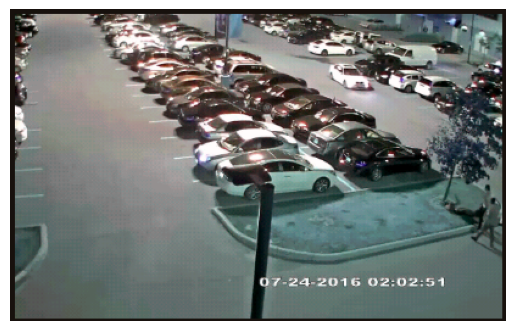

In [5]:
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO(model_name)  # your trained model
results = model('demo/img11.PNG', conf = 0.1)  # inference with confidence threshold of 0.25

# Display the result
img = results[0].plot()  # get annotated image
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO(model_name)
results = model('demo', conf = 0.05)  # or 'video.mp4' or 'folder/'

for result in results:
    img = result.plot()
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [6]:
result = model.val(data='data.yaml', imgsz=320, batch=16, device='cpu')
print(result)

Ultralytics 8.4.9  Python-3.12.10 torch-2.10.0+cpu CPU (Intel Core(TM) i7-6820HQ 2.70GHz)


val: Fast image access  (ping: 0.40.0 ms, read: 111.329.6 MB/s, size: 117.6 KB)
val: Scanning data\labels\val.cache... 3000 images, 297 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3000/3000  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 1.3it/s 2:260.8ss
                   all       3000       2865      0.712      0.704      0.754      0.425
Speed: 0.3ms preprocess, 40.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\Dell\runs\detect\val14
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000172F3FDB0B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.00

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import time

model = YOLO(model_name)
cap = cv2.VideoCapture('demovid/vid4.avi')

prev_box = None
prev_conf = 0.0
alpha = 0.8
show = False
box = None

CONF_ON  = 0.3
CONF_OFF = 0.1
STICK_WEIGHT = 0.7

k = 5.0  # stickiness factor

def l1_center_dist(prev_box, boxes):
    px = (prev_box[0] + prev_box[2]) * 0.5
    py = (prev_box[1] + prev_box[3]) * 0.5

    cx = (boxes[:,0] + boxes[:,2]) * 0.5
    cy = (boxes[:,1] + boxes[:,3]) * 0.5

    return np.abs(cx - px) + np.abs(cy - py)

start_time = time.time()



while True:
    ret, frame = cap.read()
    if not ret:
        break

    if time.time() - start_time > 0.3:  # limit to ~3 FPS
        results = model(frame, conf=0.25)
        r = results[0]

        if len(r.boxes) > 0:
            boxes = r.boxes.xyxy.cpu().numpy()
            confs = r.boxes.conf.cpu().numpy()

            areas = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])

            d = l1_center_dist(prev_box, boxes) / (frame.shape[1] + frame.shape[0]) if prev_box is not None else 0.0
            stick = np.clip(1.0 - k * d, 0.0, 1.0)

            scores = confs * areas * (1.0 + STICK_WEIGHT * stick)

            idx  = scores.argmax()
            box  = boxes[idx]
            conf = confs[idx]
        else:
            box = None
            conf = 0.0

    if box is not None:
        if prev_box is None:
            smooth_box  = box
            smooth_conf = conf
        else:
            smooth_box  = alpha * prev_box + (1 - alpha) * box
            smooth_conf = 0.8 * prev_conf + 0.2 * conf

        prev_box  = smooth_box
        prev_conf = smooth_conf

    # hysteresis
    if prev_conf > CONF_ON:
        show = True
    elif prev_conf < CONF_OFF:
        show = False

    

    if show and prev_box is not None:
        x1, y1, x2, y2 = map(int, prev_box)
        cv2.rectangle(frame, (x1,y1), (x2,y2), (0,0,255), 2)
        cv2.putText(frame, f'conf:{prev_conf:.2f}', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,255), 2)

    cv2.imshow("demo", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


cap.release()
cv2.destroyAllWindows()

In [ ]:
model.export(format='onnx', imgsz=320, device='cpu')

In [ ]:
import onnxruntime as ort
import numpy as np
import cv2
import time

# ---- Load model ----
session = ort.InferenceSession(
    "best.onnx",
    providers=["CPUExecutionProvider"]
)

input_name = session.get_inputs()[0].name

# ---- Prepare image ----
img = cv2.imread("demo/img1.png")
img = cv2.resize(img, (320, 320))
img = img.transpose(2, 0, 1)
img = np.expand_dims(img, axis=0).astype(np.float32) / 255.0

# ---- Warmup (very important) ----
for _ in range(10):
    session.run(None, {input_name: img})

# ---- Speed Test ----
runs = 100
start = time.time()

for _ in range(runs):
    session.run(None, {input_name: img})

end = time.time()

avg_time = (end - start) / runs
fps = 1 / avg_time

print(f"Average inference time: {avg_time*1000:.2f} ms")
print(f"FPS: {fps:.2f}")



In [10]:
import cv2
import numpy as np
import time
from ultralytics import YOLO

def l1_center_dist_matrix(tracked_boxes, detected_boxes):
    """Returns (N_tracked x N_detected) distance matrix."""
    def centers(b):
        return np.stack([(b[:,0]+b[:,2])*0.5, (b[:,1]+b[:,3])*0.5], axis=1)
    tc = centers(tracked_boxes)   # (N, 2)
    dc = centers(detected_boxes)  # (M, 2)
    # broadcast: (N,1,2) - (1,M,2) -> (N,M)
    diff = np.abs(tc[:,None,:] - dc[None,:,:])
    return diff.sum(axis=2)  # (N, M)

# ===== CONFIG =====
FPS_VIDEO         = 30
TOTAL_TIME_DETECT = 5
FRAME_PER_DETECT  = 50
DETECT_INTERVAL   = int(FPS_VIDEO * TOTAL_TIME_DETECT / FRAME_PER_DETECT)

MAX_TRACKS  = 5
CONF_ON     = 0.3
CONF_OFF    = 0.1
k           = 5.0
STICK_WEIGHT = 0.7
alpha       = 0.8   # smoothing (higher = slower to follow new detections)

COLORS = [
    (0,   0,   255),
    (0,   255, 0  ),
    (255, 0,   0  ),
    (0,   255, 255),
    (255, 0,   255),
]

# ===== LOAD =====
model = YOLO("best.pt")
cap   = cv2.VideoCapture("demovid/vid5.avi")

# Each track: {'box': np.array, 'conf': float, 'show': bool}
tracks    = []
raw_boxes = []   # latest detection results (up to MAX_TRACKS)
raw_confs = []

frame_id   = 0
start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    H, W = frame.shape[:2]

    # ===== YOLO EVERY N FRAMES =====
    if frame_id % DETECT_INTERVAL == 0:
        results = model(frame, conf=0.25, verbose=False)
        r       = results[0]

        raw_boxes = []
        raw_confs = []

        if len(r.boxes) > 0:
            boxes = r.boxes.xyxy.cpu().numpy()
            confs = r.boxes.conf.cpu().numpy()
            areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])

            # Score all detections using stickiness toward existing tracks
            if tracks:
                prev = np.array([t['box'] for t in tracks])          # (N, 4)
                dist_mat = l1_center_dist_matrix(prev, boxes) / (W + H)  # (N, M)
                # best stickiness per detection = max across all tracks
                best_stick = np.clip(1.0 - k * dist_mat.min(axis=0), 0.0, 1.0)
            else:
                best_stick = np.zeros(len(boxes))

            scores = confs * areas * (1.0 + STICK_WEIGHT * best_stick)

            # Pick top-MAX_TRACKS detections by score
            top_idx = np.argsort(scores)[::-1][:MAX_TRACKS]
            raw_boxes = boxes[top_idx]
            raw_confs = confs[top_idx]

    # ===== MATCH DETECTIONS TO EXISTING TRACKS =====
    if len(raw_boxes) > 0:
        det_boxes = np.array(raw_boxes)
        det_confs = np.array(raw_confs)

        if not tracks:
            # Bootstrap: create a track for every detection
            tracks = [
                {'box': det_boxes[i], 'conf': det_confs[i], 'show': False}
                for i in range(len(det_boxes))
            ]
        else:
            prev     = np.array([t['box'] for t in tracks])
            dist_mat = l1_center_dist_matrix(prev, det_boxes) / (W + H)  # (N, M)

            matched_det  = set()
            matched_trk  = set()

            # Greedy nearest-neighbour matching
            flat_order = np.argsort(dist_mat, axis=None)
            for idx in flat_order:
                ti, di = divmod(int(idx), dist_mat.shape[1])
                if ti in matched_trk or di in matched_det:
                    continue
                # Smooth matched track
                tracks[ti]['box']  = alpha * tracks[ti]['box']  + (1-alpha) * det_boxes[di]
                tracks[ti]['conf'] = alpha * tracks[ti]['conf'] + (1-alpha) * det_confs[di]
                matched_trk.add(ti)
                matched_det.add(di)
                if len(matched_trk) == min(len(tracks), len(det_boxes)):
                    break

            # Unmatched detections → new tracks (up to MAX_TRACKS)
            for di in range(len(det_boxes)):
                if di not in matched_det and len(tracks) < MAX_TRACKS:
                    tracks.append({
                        'box':  det_boxes[di],
                        'conf': det_confs[di],
                        'show': False
                    })

            # Unmatched tracks → decay confidence
            for ti in range(len(tracks)):
                if ti not in matched_trk:
                    tracks[ti]['conf'] *= 0.5   # decay; tweak as needed

            # Prune dead tracks
            tracks = [t for t in tracks if t['conf'] >= CONF_OFF]

    # ===== HYSTERESIS PER TRACK =====
    for t in tracks:
        if t['conf'] >= CONF_ON:
            t['show'] = True
        elif t['conf'] < CONF_OFF:
            t['show'] = False

    # ===== DRAW =====
    for i, t in enumerate(tracks):
        if not t['show']:
            continue
        color = COLORS[i % len(COLORS)]
        x1, y1, x2, y2 = map(int, t['box'])
        cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)
        cv2.putText(frame, f"#{i} {t['conf']:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow("demo", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_id += 1

elapsed = time.time() - start_time
print(f"Processed {frame_id} frames in {elapsed:.2f}s ({frame_id/elapsed:.2f} FPS)")

cap.release()
cv2.destroyAllWindows()

Processed 150 frames in 4.68s (32.05 FPS)


In [46]:
import cv2
import numpy as np
import time
from ultralytics import YOLO

# ===== TRACKER FACTORY =====
TRACKER_TYPE = "MOSSE"  # or "MEDIANFLOW"

def make_tracker():
    if TRACKER_TYPE == "MOSSE":
        return cv2.legacy.TrackerMOSSE_create()
    elif TRACKER_TYPE == "MEDIANFLOW":
        return cv2.legacy.TrackerMedianFlow_create()
    raise ValueError(f"Unknown tracker: {TRACKER_TYPE}")

def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return (x1, y1, x2 - x1, y2 - y1)

def xywh_to_xyxy(box):
    x, y, w, h = box
    return np.array([x, y, x + w, y + h], dtype=float)

def l1_center_dist_matrix(tracked_boxes, detected_boxes):
    def centers(b):
        return np.stack([(b[:,0]+b[:,2])*0.5, (b[:,1]+b[:,3])*0.5], axis=1)
    tc = centers(tracked_boxes)
    dc = centers(detected_boxes)
    diff = np.abs(tc[:,None,:] - dc[None,:,:])
    return diff.sum(axis=2)

def merge_overlapping_tracks(tracks, iou_threshold=0.45):
    """
    Merge pairs of tracks whose boxes overlap above iou_threshold.
    Keeps the higher-conf track, discards the other.
    Runs repeatedly until no more merges needed.
    """
    if len(tracks) <= 1:
        return tracks

    def iou(a, b):
        ax1, ay1, ax2, ay2 = a
        bx1, by1, bx2, by2 = b
        ix1 = max(ax1, bx1); iy1 = max(ay1, by1)
        ix2 = min(ax2, bx2); iy2 = min(ay2, by2)
        iw = max(0.0, ix2 - ix1)
        ih = max(0.0, iy2 - iy1)
        inter = iw * ih
        if inter == 0:
            return 0.0
        area_a = (ax2-ax1) * (ay2-ay1)
        area_b = (bx2-bx1) * (by2-by1)
        return inter / (area_a + area_b - inter)

    changed = True
    while changed:
        changed = False
        keep = [True] * len(tracks)
        for i in range(len(tracks)):
            if not keep[i]:
                continue
            for j in range(i+1, len(tracks)):
                if not keep[j]:
                    continue
                if iou(tracks[i]['box'], tracks[j]['box']) >= iou_threshold:
                    # keep higher conf, absorb the other's conf slightly
                    winner, loser = (i, j) if tracks[i]['conf'] >= tracks[j]['conf'] else (j, i)
                    tracks[winner]['conf'] = max(tracks[winner]['conf'], tracks[loser]['conf'])
                    keep[loser] = False
                    changed = True
        tracks = [t for i, t in enumerate(tracks) if keep[i]]

    return tracks

# ===== CONFIG =====
FPS_VIDEO         = 30
TOTAL_TIME_DETECT = 2.5
FRAME_PER_DETECT  = 8
DETECT_INTERVAL   = int(FPS_VIDEO * TOTAL_TIME_DETECT / FRAME_PER_DETECT)

MAX_TRACKS   = 5
CONF_ON      = 0.25
CONF_OFF     = 0.1
k            = 5.0
STICK_WEIGHT = 0.7
alpha        = 0.8

COLORS = [
    (0,   0,   255),
    (0,   255, 0  ),
    (255, 0,   0  ),
    (0,   255, 255),
    (255, 0,   255),
]

# ===== LOAD =====
model = YOLO("best.pt")
cap   = cv2.VideoCapture("demovid/vid6.avi")

# Each track:
#   box    : np.array xyxy   (smoothed)
#   conf   : float
#   show   : bool
#   tracker: cv2 tracker instance or None
#   tracker_ok: bool  (False = tracker failed, use last known box until YOLO)
tracks    = []
raw_boxes = []
raw_confs = []

frame_id   = 0
start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    H, W = frame.shape[:2]
    is_detect_frame = (frame_id % DETECT_INTERVAL == 0)

    # ===== BETWEEN-FRAME TRACKING =====
    if not is_detect_frame:
        for t in tracks:
            if t['tracker'] is None or not t['tracker_ok']:
                # tracker failed or not yet initialized → hold position
                continue

            ok, new_xywh = t['tracker'].update(frame)
            if ok:
                new_box = xywh_to_xyxy(new_xywh)
                # sanity check: box must stay within frame
                if (new_box[0] >= 0 and new_box[1] >= 0 and
                    new_box[2] <= W  and new_box[3] <= H  and
                    new_box[2] > new_box[0] and new_box[3] > new_box[1]):
                    t['box'] = alpha * t['box'] + (1 - alpha) * new_box
                    t['tracker_ok'] = True
                else:
                    t['tracker_ok'] = False  # out-of-bounds → treat as failed
            else:
                t['tracker_ok'] = False  # tracker lost target

    # ===== YOLO DETECTION =====
    if is_detect_frame:
        results = model(frame, conf=0.1, verbose=False)
        r       = results[0]

        raw_boxes = []
        raw_confs = []

        if len(r.boxes) > 0:
            boxes = r.boxes.xyxy.cpu().numpy()
            confs = r.boxes.conf.cpu().numpy()
            areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])

            if tracks:
                prev     = np.array([t['box'] for t in tracks])
                dist_mat = l1_center_dist_matrix(prev, boxes) / (W + H)
                best_stick = np.clip(1.0 - k * dist_mat.min(axis=0), 0.0, 1.0)
            else:
                best_stick = np.zeros(len(boxes))

            scores  = confs * areas * (1.0 + STICK_WEIGHT * best_stick)
            top_idx = np.argsort(scores)[::-1][:MAX_TRACKS]
            raw_boxes = boxes[top_idx]
            raw_confs = confs[top_idx]

        # ===== MATCH YOLO → TRACKS =====
        if len(raw_boxes) > 0:
            det_boxes = np.array(raw_boxes)
            det_confs = np.array(raw_confs)

            if not tracks:
                for i in range(len(det_boxes)):
                    tr = make_tracker()
                    tr.init(frame, xyxy_to_xywh(det_boxes[i]))
                    tracks.append({
                        'box':        det_boxes[i],
                        'conf':       det_confs[i],
                        'show':       False,
                        'tracker':    tr,
                        'tracker_ok': True,
                    })
                    tracks = merge_overlapping_tracks(tracks) 
            else:
                prev     = np.array([t['box'] for t in tracks])
                dist_mat = l1_center_dist_matrix(prev, det_boxes) / (W + H)

                matched_det = set()
                matched_trk = set()

                flat_order = np.argsort(dist_mat, axis=None)
                for idx in flat_order:
                    ti, di = divmod(int(idx), dist_mat.shape[1])
                    if ti in matched_trk or di in matched_det:
                        continue
                    # Re-init tracker on every YOLO frame for matched tracks
                    # (corrects any tracker drift)
                    tr = make_tracker()
                    tr.init(frame, xyxy_to_xywh(det_boxes[di]))
                    tracks[ti]['box']        = alpha * tracks[ti]['box'] + (1-alpha) * det_boxes[di]
                    tracks[ti]['conf']       = alpha * tracks[ti]['conf'] + (1-alpha) * det_confs[di]
                    tracks[ti]['tracker']    = tr
                    tracks[ti]['tracker_ok'] = True
                    matched_trk.add(ti)
                    matched_det.add(di)
                    if len(matched_trk) == min(len(tracks), len(det_boxes)):
                        break

                # Unmatched detections → new tracks
                for di in range(len(det_boxes)):
                    if di not in matched_det and len(tracks) < MAX_TRACKS:
                        tr = make_tracker()
                        tr.init(frame, xyxy_to_xywh(det_boxes[di]))
                        tracks.append({
                            'box':        det_boxes[di],
                            'conf':       det_confs[di],
                            'show':       False,
                            'tracker':    tr,
                            'tracker_ok': True,
                        })

                # Unmatched tracks → decay
                for ti in range(len(tracks)):
                    if ti not in matched_trk:
                        tracks[ti]['conf']       *= 0.5
                        tracks[ti]['tracker_ok']  = False  # don't trust tracker either

        else:
            # YOLO found nothing → decay all tracks
            for t in tracks:
                t['conf']       *= 0.5
                t['tracker_ok']  = False

        # Prune dead tracks
        tracks = [t for t in tracks if t['conf'] >= CONF_OFF]
        tracks = merge_overlapping_tracks(tracks) 

    # ===== HYSTERESIS =====
    for t in tracks:
        if t['conf'] >= CONF_ON:
            t['show'] = True
        elif t['conf'] < CONF_OFF:
            t['show'] = False

    # ===== DRAW =====
    for i, t in enumerate(tracks):
        if not t['show']:
            continue
        color = COLORS[i % len(COLORS)]
        x1, y1, x2, y2 = map(int, t['box'])
        cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)

        # Show tracker status in label
        status = "OK" if t['tracker_ok'] else "HOLD"
        cv2.putText(frame, f"#{i} {t['conf']:.2f} [{status}]", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    cv2.imshow("demo", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_id += 1

elapsed = time.time() - start_time
print(f"Processed {frame_id} frames in {elapsed:.2f}s ({frame_id/elapsed:.2f} FPS)")

cap.release()
cv2.destroyAllWindows()

Processed 150 frames in 3.82s (39.24 FPS)
